# 009 - Brute Force QUBO portfolio Notebook - Fetched Assets

## Admin 

In [1]:
# Load Libraties 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qubo_functions import (
    compute_expected_return_vector,
    compute_covariance_matrix,
    build_qubo_matrix_mean_variance,
    generate_all_binary_portfolios,
    evaluate_all_binary_portfolios,
    find_optimal_portfolio_by_energy,
    export_qubo_terms_for_qaoa,
)

import environment as envir 
from tabulate import tabulate 

import Quantum_Optimization_Functions as qof 


In [2]:
data, headers = envir.environment_state()
print(tabulate(data, headers=headers, tablefmt="grid"))

+-------------------------+-----------+
| System/Library          | Version   |
+=========================+===========+
| Python                  | 3.10.9    |
+-------------------------+-----------+
| numpy                   | 2.2.6     |
+-------------------------+-----------+
| torch                   | 2.9.1     |
+-------------------------+-----------+
| matplotlib              | 3.10.8    |
+-------------------------+-----------+
| seaborn                 | 0.13.2    |
+-------------------------+-----------+
| qiskit                  | 1.4.4     |
+-------------------------+-----------+
| qiskit_machine_learning | 0.8.4     |
+-------------------------+-----------+
| yfinance                | 1.2.0     |
+-------------------------+-----------+


### Set System Parameters 

In [3]:
debug_print = True
Purchase_Budget = 1000

### Step 1 - Fetch Assets with Returns Data 

In [4]:
# Target_Tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'JPM', 'XOM', 'JNJ', 'V']
# summary_df, Asset_Returns_DataFrame = qof.get_assets(companies_list = Target_Tickers)
summary_df, Asset_Returns_DataFrame = qof.get_assets(sample_size = 5)
Asset_Names = Asset_Returns_DataFrame.columns
Number_of_Assets = Asset_Returns_DataFrame.shape[1] 

Asset_Returns_DataFrame = Asset_Returns_DataFrame.reset_index(drop=True)

if debug_print: 
    display(Asset_Returns_DataFrame.head())

,MET,GEN,BG,AKAM,PFG
0,0.002290,0.002812,0.028513,0.014409,0.016024
1,0.001713,-0.011218,-0.008969,-0.005395,-0.001262
2,-0.009407,-0.001621,-0.007313,0.001550,-0.009980
3,-0.001295,-0.003653,0.016576,0.027302,0.001148
4,0.007348,-0.017108,-0.003986,-0.004949,0.030716


### Step 2 - Compute the Expected Returns and Covariance Matrix 

In [5]:
Expected_Return_Vector = compute_expected_return_vector(
    Asset_Returns_DataFrame=Asset_Returns_DataFrame
)

Sigma_Covariance_Matrix = compute_covariance_matrix(
    Asset_Returns_DataFrame=Asset_Returns_DataFrame
)

if debug_print: 
    print("Expected_Return_Vector:")
    print(Expected_Return_Vector)
    print("\nSigma_Covariance_Matrix:")
    print(Sigma_Covariance_Matrix)

Expected_Return_Vector:
[ 0.00073838  0.00080104 -0.00099635 -0.00010888  0.00023171]

Sigma_Covariance_Matrix:
[[3.47111290e-04 1.65208173e-04 1.13222330e-04 2.25553303e-04
  2.95369727e-04]
 [1.65208173e-04 2.94140511e-04 7.66560627e-05 1.83952421e-04
  1.85488278e-04]
 [1.13222330e-04 7.66560627e-05 3.30720275e-04 6.58818373e-05
  1.20016770e-04]
 [2.25553303e-04 1.83952421e-04 6.58818373e-05 6.94386352e-04
  2.35014882e-04]
 [2.95369727e-04 1.85488278e-04 1.20016770e-04 2.35014882e-04
  3.42266343e-04]]


### Step 3 - Build the QUBO Matrix 

In [6]:
Risk_Aversion_Parameter = 10.0  # adjust as desired

Q_Matrix = build_qubo_matrix_mean_variance(
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Risk_Aversion_Parameter=Risk_Aversion_Parameter,
)

if debug_print: 
    print("\nQ_Matrix:")
    print(Q_Matrix)


Q_Matrix:
[[0.00273274 0.00165208 0.00113222 0.00225553 0.0029537 ]
 [0.00165208 0.00214036 0.00076656 0.00183952 0.00185488]
 [0.00113222 0.00076656 0.00430355 0.00065882 0.00120017]
 [0.00225553 0.00183952 0.00065882 0.00705274 0.00235015]
 [0.0029537  0.00185488 0.00120017 0.00235015 0.00319095]]


### Step 4 - Generate all binary portfolios 

In [7]:
Binary_Portfolios = generate_all_binary_portfolios(
    Number_of_Assets=Number_of_Assets
)

Binary_Portfolios_1 = Binary_Portfolios.pop(0)

if debug_print: 
    print(f"\nNumber of binary portfolios: {len(Binary_Portfolios)}")


Number of binary portfolios: 31


### Step 5 - Evaluate all portfolios, risk, and returns 

In [8]:
Evaluation_DataFrame = evaluate_all_binary_portfolios(
    Binary_Portfolios=Binary_Portfolios,
    Q_Matrix=Q_Matrix,
    Expected_Return_Vector=Expected_Return_Vector,
    Sigma_Covariance_Matrix=Sigma_Covariance_Matrix,
    Asset_Names=Asset_Names,
)

display(Evaluation_DataFrame.head())

,Binary_Portfolio,Energy,Portfolio_Return,Portfolio_Risk,MET_Included,GEN_Included,BG_Included,AKAM_Included,PFG_Included
0,"(0, 0, 0, 0, 1)",0.003191,0.000232,0.000342,0,0,0,0,1
1,"(0, 0, 0, 1, 0)",0.007053,-0.000109,0.000694,0,0,0,1,0
2,"(0, 0, 0, 1, 1)",0.014944,0.000123,0.001507,0,0,0,1,1
3,"(0, 0, 1, 0, 0)",0.004304,-0.000996,0.000331,0,0,1,0,0
4,"(0, 0, 1, 0, 1)",0.009895,-0.000765,0.000913,0,0,1,0,1


### Step 6 - Identified optimized portfolio by minumum energy 

In [9]:
Optimal_Portfolio_Row = find_optimal_portfolio_by_energy(
    Evaluation_DataFrame=Evaluation_DataFrame
)

print("\nOptimal portfolio by energy:")
display(Optimal_Portfolio_Row)

print("\nOptimal binary portfolio:", Optimal_Portfolio_Row["Binary_Portfolio"])
print("Optimal energy:", Optimal_Portfolio_Row["Energy"])
print("Optimal portfolio return:", Optimal_Portfolio_Row["Portfolio_Return"])
print("Optimal portfolio risk:", Optimal_Portfolio_Row["Portfolio_Risk"]) 


Optimal portfolio by energy:


Binary_Portfolio    (0, 1, 0, 0, 0)
Energy                      0.00214
Portfolio_Return           0.000801
Portfolio_Risk             0.000294
MET_Included                      0
GEN_Included                      1
BG_Included                       0
AKAM_Included                     0
PFG_Included                      0
Name: 7, dtype: object


Optimal binary portfolio: (0, 1, 0, 0, 0)
Optimal energy: 0.0021403648708280118
Optimal portfolio return: 0.0008010402341843562
Optimal portfolio risk: 0.0002941405105012368


### Step 7 - Visualization of responses

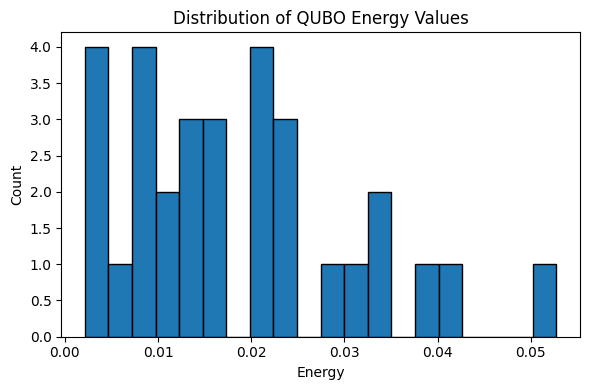

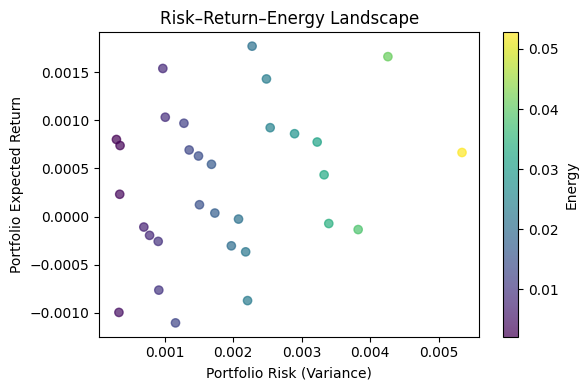

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(Evaluation_DataFrame["Energy"], bins=20, edgecolor="black")
plt.xlabel("Energy")
plt.ylabel("Count")
plt.title("Distribution of QUBO Energy Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(
    Evaluation_DataFrame["Portfolio_Risk"],
    Evaluation_DataFrame["Portfolio_Return"],
    c=Evaluation_DataFrame["Energy"],
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(label="Energy")
plt.xlabel("Portfolio Risk (Variance)")
plt.ylabel("Portfolio Expected Return")
plt.title("Risk–Return–Energy Landscape")
plt.tight_layout()
plt.show() 

### Step 8 = Export the QUBO terms for a QAOA analysis 

In [11]:
QUBO_Terms_Dictionary = export_qubo_terms_for_qaoa(
    Q_Matrix=Q_Matrix
)

print("\nLinear terms (first few):")
for k in list(QUBO_Terms_Dictionary["linear_terms"].keys())[:5]:
    print(k, ":", QUBO_Terms_Dictionary["linear_terms"][k])

print("\nQuadratic terms (first few):")
for k in list(QUBO_Terms_Dictionary["quadratic_terms"].keys())[:5]:
    print(k, ":", QUBO_Terms_Dictionary["quadratic_terms"][k])

Linear_Terms_DataFrame = pd.DataFrame(
    list(QUBO_Terms_Dictionary["linear_terms"].items()),
    columns=["Asset_Index", "Linear_Coefficient"]
)

Quadratic_Terms_DataFrame = pd.DataFrame(
    [(i, j, value) for (i, j), value in QUBO_Terms_Dictionary["quadratic_terms"].items()],
    columns=["Asset_i", "Asset_j", "Quadratic_Coefficient"]
)

QUBO_Linear_Terms_Out = "../data/QUBO_linear_terms.csv"
QUBO_Quadratic_Terms_Out = "../data/QUBO_quadratic_terms.csv"


Linear_Terms_DataFrame.to_csv(QUBO_Linear_Terms_Out, index=False)
Quadratic_Terms_DataFrame.to_csv(QUBO_Quadratic_Terms_Out, index=False)



Linear terms (first few):
0 : 0.0027327356008318465
1 : 0.0021403648708280118
2 : 0.00430355462588334
3 : 0.007052738684967216
4 : 0.003190949391576963

Quadratic terms (first few):
(0, 1) : 0.0016520817331365065
(0, 2) : 0.001132223303522791
(0, 3) : 0.0022555330284291203
(0, 4) : 0.002953697267143775
(1, 2) : 0.0007665606270898725
